In [15]:
# Import libaries and modules
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import svm
import warnings

print("[i] INFO - Program has been initialised")

[i] INFO - Program has been initialised


In [16]:
# Filter early stoppage warnings
warnings.filterwarnings(
    "ignore",
    message="Best weights from best epoch are automatically used!"
    
)

In [18]:
# Pre-define variables
rs = 1
folder, file = 'datasets', 'dataset.csv'

In [19]:
def load_dataset():
    '''
    Loads the dataset from the specified path. 

    Parameters:
        None

    Returns:
        df
    '''
    
    print(f"[i] INFO - Loading '{file}' dataset...")
    path = os.path.join(folder, file)
    
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f" [!] ERROR - No file found at '{path}'")
        input();sys.exit(1)
    except PermissionError:
        print(f" [!] ERROR - No permission to read '{path}'")
        input();sys.exit(1)
    except UnicodeDecodeError:
        print(f" [!] ERROR - Unable to decode '{path}'")
        input();sys.exit(1)
    except pd.errors.EmptyDataError:
        print(f" [!] ERROR - No data found in '{path}'")
        input();sys.exit(1)
    except pd.errors.ParserError:
        print(f" [!] ERROR - Unable to parse data found in '{path}'")
        input();sys.exit(1)

    print(f"[~] DEBUG - Loaded dataset with shape: ({df.shape[0]} x {df.shape[1]})")
        
    return df

In [20]:
def prepare_dataframe(df):
    '''
    Prepare the dataframe by splitting into testing and training sets, encoding and standardizing the features.

    Parameters:
        df

    Returns:
        x_train_scl, x_test_scl, y_train_enc, y_test_enc, le
    '''

    print(f"[i] INFO - Preparing '{file}' dataframe...")

    # Split dataframe into testing and training sets
    print("[i] INFO - Splitting the dataframe into testing and training sets...")
    x, y = df.drop(columns=['Label']), df["Label"]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=rs, stratify=y)

    print(f"[~] DEBUG - New dataset shape: ({x_train.shape[0]} x {x_train.shape[1]}) and ({x_test.shape[0]} x {x_test.shape[1]})")
    
    # Encode categories as an integer value
    print("[i] INFO - Encoding the categories...")
    le = LabelEncoder()
    y_train_enc, y_test_enc = le.fit_transform(y_train), le.transform(y_test)
    
    # Standardize the features of the dataframe
    print("[i] INFO - Standardizing the features...")
    scaler = StandardScaler()
    x_train_scl = scaler.fit_transform(x_train)
    x_test_scl  = scaler.transform(x_test)

    return x_train_scl, x_test_scl, y_train_enc, y_test_enc, le

In [21]:
def calculate_score(x_test_scl, y_test_enc, model, le, name):
    '''
    Calculate and display the confusion matrix of the model.

    Parameters:
        x_test_scl, y_test_enc, model, le, name

    Returns:
        None
    '''

    img_name = f"confusion_matrix_{name}.png"
    
    print("[i] INFO - Calculating the scores of the model...")
    y_pred = model.predict(x_test_scl)

    # Calculate the confusion matrix for the model
    cm = confusion_matrix(y_test_enc, y_pred)

    # Display the confusion matrix and save it as an image
    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.title(f"Confusion Matrix - {name}", color="white")
    plt.xlabel("Predicted", color="white")
    plt.ylabel("Actual", color="white")

    ax.tick_params(axis="x", colors="white")
    ax.tick_params(axis="y", colors="white")

    for spine in ax.spines.values():
        spine.set_edgecolor("white")
    
    cbar = disp.im_.colorbar
    cbar.ax.tick_params(colors="white")
    cbar.outline.set_edgecolor("white")
    for spine in cbar.ax.spines.values():
        spine.set_edgecolor("white")

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    plt.tight_layout()
    print("[i] INFO - Saving the confusion matrix to a file...")
    fig.savefig(f"confusion_matrix_{name}.png", transparent=True)
    print(f"[~] DEBUG - Image has been saved as {img_name}")
    plt.show()

    # Calculate and show the classification report for the model
    rep = classification_report(y_test_enc, y_pred, target_names=le.classes_, digits=4)
    print(f"\n{rep}")

    return

In [22]:
def logistic_regression(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le): 
    '''
    Evaluate logistic regression model using the processed dataset. 

    Parameters:
        x_train_scl, x_test_scl, y_train_enc, y_test_enc, le

    Returns:
        None
    '''
    
    print("[i] INFO - Evaluating the logistic regression model...")
    name = "LR"
    
    # Perform logistic regression training
    print("[i] INFO - Training the model...")
    model = LogisticRegression(max_iter=10000, random_state=rs)
    model.fit(x_train_scl, y_train_enc)

    # Calculate the score of the model
    calculate_score(x_test_scl, y_test_enc, model, le, name)
    
    return

In [23]:
def support_vector_machine(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le):
    
    '''
    Evaluate support vector machine model using the processed dataset. 

    Parameters:
        x_train_scl, x_test_scl, y_train_enc, y_test_enc, le

    Returns:
        None
    '''
    
    print("[i] INFO - Evaluating the support vector machine model...")
    name = "SVM"
    
    # Perform support vector machine training
    print("[i] INFO - Training the model...")
    model = svm.SVC(kernel='linear', random_state=rs)
    model.fit(x_train_scl, y_train_enc)

    # Calculate the score of the model
    calculate_score(x_test_scl, y_test_enc, model, le, name)   

    return

In [24]:
def k_nearest_neighbours(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le):
    '''
    Evaluate k-nearest neighbours model using the processed dataset. 

    Parameters:
        x_train_scl, x_test_scl, y_train_enc, y_test_enc, le

    Returns:
        None
    '''

    print("[i] INFO - Evaluating the k-nearest neighbour model...")
    name = "KNN"
    
    # Perform k-nearest neigbours training
    print("[i] INFO - Training the model...")
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(x_train_scl, y_train_enc)

    # Calculate the score of the model
    calculate_score(x_test_scl, y_test_enc, model, le, name)

    return

In [25]:
def random_forests(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le):
    '''
    Evaluate random forests model using the processed dataset. 

    Parameters:
        x_train_scl, x_test_scl, y_train_enc, y_test_enc, le

    Returns:
        None
    '''

    print("[i] INFO - Evaluating the random forests model...")
    name = "RF"
    
    # Perform random forests training
    print("[i] INFO - Training the model...")
    model = RandomForestClassifier(n_estimators=100, random_state=rs)
    model.fit(x_train_scl, y_train_enc)

    # Calculate the score of the model
    calculate_score(x_test_scl, y_test_enc, model, le, name)

    return

In [26]:
def tabular_network(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le):
    '''
    Evaluate tabular network deep learning model using the processed dataset. 

    Parameters:
        x_train_scl, x_test_scl, y_train_enc, y_test_enc, le

    Returns:
        None
    '''

    print("[i] INFO - Evaluating the tabular network model...")
    name = "TN"
    
    # Perform tabular network training
    print("[i] INFO - Training the model...")
    model = TabNetClassifier(seed=rs, verbose=0)
    model.fit(x_train_scl, y_train_enc, eval_set=[(x_test_scl, y_test_enc)], max_epochs=100, patience=100)

    # Calculate the score of the model
    calculate_score(x_test_scl, y_test_enc, model, le, name)

    return

In [27]:
def multi_layer_perceptron(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le):
    '''
    Evaluate multi-layer perceptron deep learning model using the processed dataset. 

    Parameters:
        x_train_scl, x_test_scl, y_train_enc, y_test_enc, le

    Returns:
        None
    '''

    print("[i] INFO - Evaluating the multi-layer perceptron model...")
    name = "MLP"
    
    # Perform multi-layer perceptron training
    print("[i] INFO - Training the model...")
    model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=rs)
    model.fit(x_train_scl, y_train_enc)

    # Calculate the score of the model
    calculate_score(x_test_scl, y_test_enc, model, le, name)

    return

[i] INFO - Loading 'dataset.csv' dataset...
[~] DEBUG - Loaded dataset with shape: (100000 x 79)
[i] INFO - Preparing 'dataset.csv' dataframe...
[i] INFO - Splitting the dataframe into testing and training sets...
[~] DEBUG - New dataset shape: (75000 x 78) and (25000 x 78)
[i] INFO - Encoding the categories...
[i] INFO - Standardizing the features...
[i] INFO - Evaluating the logistic regression model...
[i] INFO - Training the model...
[i] INFO - Calculating the scores of the model...
[i] INFO - Saving the confusion matrix to a file...
[~] DEBUG - Image has been saved as confusion_matrix_LR.png


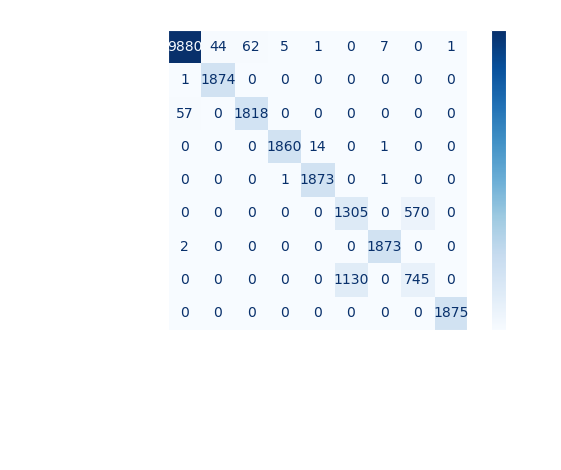


                  precision    recall  f1-score   support

          Benign     0.9940    0.9880    0.9910     10000
       DDoS-HOIC     0.9771    0.9995    0.9881      1875
       DDoS-LOIC     0.9670    0.9696    0.9683      1875
   DoS-GoldenEye     0.9968    0.9920    0.9944      1875
        DoS-Hulk     0.9921    0.9989    0.9955      1875
DoS-SlowHTTPTest     0.5359    0.6960    0.6056      1875
   DoS-Slowloris     0.9952    0.9989    0.9971      1875
  FTP-BruteForce     0.5665    0.3973    0.4671      1875
  SSH-BruteForce     0.9995    1.0000    0.9997      1875

        accuracy                         0.9241     25000
       macro avg     0.8916    0.8934    0.8896     25000
    weighted avg     0.9248    0.9241    0.9226     25000

[i] INFO - Evaluating the support vector machine model...
[i] INFO - Training the model...
[i] INFO - Calculating the scores of the model...
[i] INFO - Saving the confusion matrix to a file...
[~] DEBUG - Image has been saved as confusion_mat

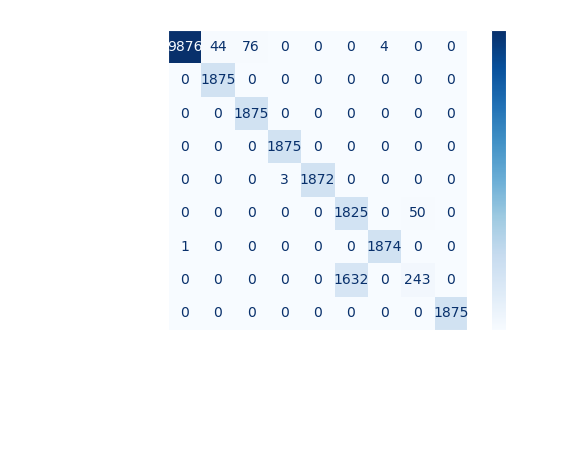


                  precision    recall  f1-score   support

          Benign     0.9999    0.9876    0.9937     10000
       DDoS-HOIC     0.9771    1.0000    0.9884      1875
       DDoS-LOIC     0.9610    1.0000    0.9801      1875
   DoS-GoldenEye     0.9984    1.0000    0.9992      1875
        DoS-Hulk     1.0000    0.9984    0.9992      1875
DoS-SlowHTTPTest     0.5279    0.9733    0.6845      1875
   DoS-Slowloris     0.9979    0.9995    0.9987      1875
  FTP-BruteForce     0.8294    0.1296    0.2242      1875
  SSH-BruteForce     1.0000    1.0000    1.0000      1875

        accuracy                         0.9276     25000
       macro avg     0.9213    0.8987    0.8742     25000
    weighted avg     0.9468    0.9276    0.9131     25000

[i] INFO - Evaluating the k-nearest neighbour model...
[i] INFO - Training the model...
[i] INFO - Calculating the scores of the model...
[i] INFO - Saving the confusion matrix to a file...
[~] DEBUG - Image has been saved as confusion_matrix

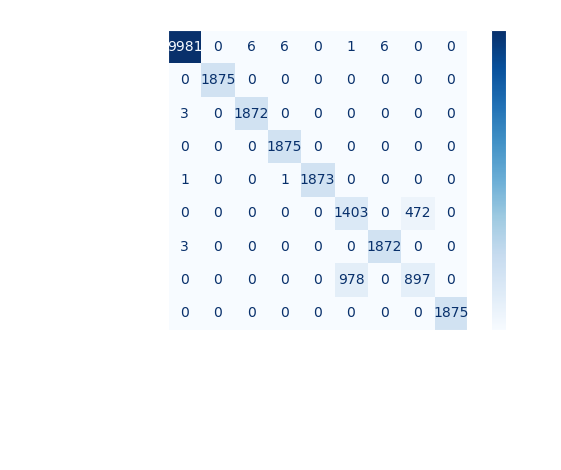


                  precision    recall  f1-score   support

          Benign     0.9993    0.9981    0.9987     10000
       DDoS-HOIC     1.0000    1.0000    1.0000      1875
       DDoS-LOIC     0.9968    0.9984    0.9976      1875
   DoS-GoldenEye     0.9963    1.0000    0.9981      1875
        DoS-Hulk     1.0000    0.9989    0.9995      1875
DoS-SlowHTTPTest     0.5890    0.7483    0.6591      1875
   DoS-Slowloris     0.9968    0.9984    0.9976      1875
  FTP-BruteForce     0.6552    0.4784    0.5530      1875
  SSH-BruteForce     1.0000    1.0000    1.0000      1875

        accuracy                         0.9409     25000
       macro avg     0.9148    0.9134    0.9115     25000
    weighted avg     0.9423    0.9409    0.9399     25000

[i] INFO - Evaluating the random forests model...
[i] INFO - Training the model...
[i] INFO - Calculating the scores of the model...
[i] INFO - Saving the confusion matrix to a file...
[~] DEBUG - Image has been saved as confusion_matrix_RF.p

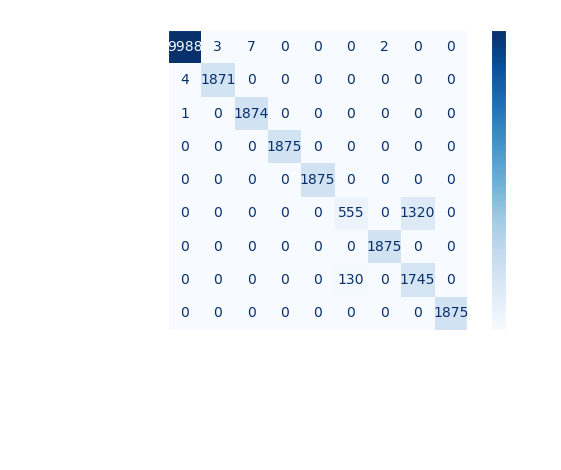


                  precision    recall  f1-score   support

          Benign     0.9995    0.9988    0.9991     10000
       DDoS-HOIC     0.9984    0.9979    0.9981      1875
       DDoS-LOIC     0.9963    0.9995    0.9979      1875
   DoS-GoldenEye     1.0000    1.0000    1.0000      1875
        DoS-Hulk     1.0000    1.0000    1.0000      1875
DoS-SlowHTTPTest     0.8102    0.2960    0.4336      1875
   DoS-Slowloris     0.9989    1.0000    0.9995      1875
  FTP-BruteForce     0.5693    0.9307    0.7065      1875
  SSH-BruteForce     1.0000    1.0000    1.0000      1875

        accuracy                         0.9413     25000
       macro avg     0.9303    0.9136    0.9039     25000
    weighted avg     0.9528    0.9413    0.9348     25000

[i] INFO - Evaluating the tabular network model...
[i] INFO - Training the model...
[i] INFO - Calculating the scores of the model...
[i] INFO - Saving the confusion matrix to a file...
[~] DEBUG - Image has been saved as confusion_matrix_TN.

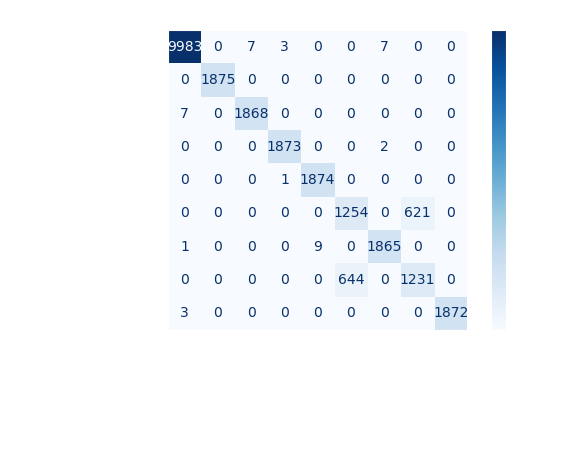


                  precision    recall  f1-score   support

          Benign     0.9989    0.9983    0.9986     10000
       DDoS-HOIC     1.0000    1.0000    1.0000      1875
       DDoS-LOIC     0.9963    0.9963    0.9963      1875
   DoS-GoldenEye     0.9979    0.9989    0.9984      1875
        DoS-Hulk     0.9952    0.9995    0.9973      1875
DoS-SlowHTTPTest     0.6607    0.6688    0.6647      1875
   DoS-Slowloris     0.9952    0.9947    0.9949      1875
  FTP-BruteForce     0.6647    0.6565    0.6606      1875
  SSH-BruteForce     1.0000    0.9984    0.9992      1875

        accuracy                         0.9478     25000
       macro avg     0.9232    0.9235    0.9233     25000
    weighted avg     0.9478    0.9478    0.9478     25000

[i] INFO - Evaluating the multi-layer perceptron model...
[i] INFO - Training the model...
[i] INFO - Calculating the scores of the model...
[i] INFO - Saving the confusion matrix to a file...
[~] DEBUG - Image has been saved as confusion_mat

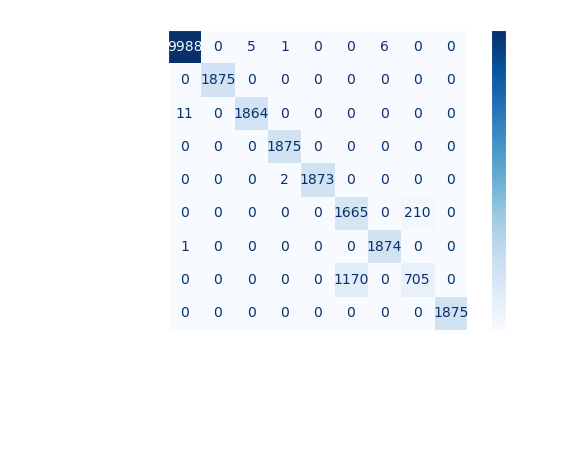


                  precision    recall  f1-score   support

          Benign     0.9988    0.9988    0.9988     10000
       DDoS-HOIC     1.0000    1.0000    1.0000      1875
       DDoS-LOIC     0.9973    0.9941    0.9957      1875
   DoS-GoldenEye     0.9984    1.0000    0.9992      1875
        DoS-Hulk     1.0000    0.9989    0.9995      1875
DoS-SlowHTTPTest     0.5873    0.8880    0.7070      1875
   DoS-Slowloris     0.9968    0.9995    0.9981      1875
  FTP-BruteForce     0.7705    0.3760    0.5054      1875
  SSH-BruteForce     1.0000    1.0000    1.0000      1875

        accuracy                         0.9438     25000
       macro avg     0.9277    0.9173    0.9115     25000
    weighted avg     0.9508    0.9438    0.9399     25000

[i] INFO - Program has finished execution


In [28]:
def main():
    '''
    Evaluate each machine learning model.

    Parameters:
        None

    Returns:
        None
    '''
    # Load the dataset
    df = load_dataset()

    # Prepare the dataset
    x_train_scl, x_test_scl, y_train_enc, y_test_enc, le = prepare_dataframe(df)
    
    # Evaluate the logistic regression model
    logistic_regression(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le)
    
    # Evaluate the support vector machine model
    support_vector_machine(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le)

    # Evaluate the k-nearest neighbours model
    k_nearest_neighbours(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le)
    
    # Evaluate the random forests model
    random_forests(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le)

    # Evaluate the tabular network model
    tabular_network(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le)
    
    # Evaluate the multi-layer perceptron model
    multi_layer_perceptron(x_train_scl, x_test_scl, y_train_enc, y_test_enc, le)

    print("[i] INFO - Program has finished execution")
    
if __name__ == "__main__":
    main()